In [1]:
import os
Directories = [
    "./data",
    "./checkpoints",
    "./outputs",
    "./outputs/kernels",
    "./output/confusion_matrices"
]

for d in Directories:
    os.makedirs(d, exist_ok=True)
    print(f"done")

print(f"Directory: {os.getcwd()}")



done
done
done
done
done
Directory: C:\Users\CREWMOBILE\Desktop\Assignment 2 cnn


In [5]:
%pip install wandb

   ---------------------------------------- 0.0/27.0 MB ? eta -:--:--
   -- ------------------------------------- 1.8/27.0 MB 10.0 MB/s eta 0:00:03
   ----- ---------------------------------- 3.7/27.0 MB 10.4 MB/s eta 0:00:03
   -------- ------------------------------- 5.8/27.0 MB 9.8 MB/s eta 0:00:03
   ------------ --------------------------- 8.1/27.0 MB 10.1 MB/s eta 0:00:02
   --------------- ------------------------ 10.7/27.0 MB 10.6 MB/s eta 0:00:02
   ------------------- -------------------- 13.4/27.0 MB 11.0 MB/s eta 0:00:02
   ----------------------- ---------------- 16.0/27.0 MB 11.2 MB/s eta 0:00:01
   --------------------------- ------------ 18.4/27.0 MB 11.1 MB/s eta 0:00:01
   ------------------------------ --------- 20.4/27.0 MB 11.0 MB/s eta 0:00:01
   ---------------------------------- ----- 23.1/27.0 MB 11.2 MB/s eta 0:00:01
   ------------------------------------- -- 25.4/27.0 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 27.0/27.0 MB 11.1 MB/s

In [10]:
# the above step just created the basic directory structure for the custom_Cnnpart of the project

# Importing and seeding

import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchvision
import wandb
import sklearn

SEED = 42
# This defines a single int valude used across every pseudo-rng fn this means that anyone running this notebook will get the exact same data splits, initial wts, etc.

def seeds(seed=42):
    random.seed(seed)
    os.environ['HASH'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f" Random seed locked to {seed}")

seeds(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

 Random seed locked to 42
Using device: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


In [11]:
wandb.login()
WANDB_PROJECT = "cnn_vs_transfer_learning"
print(f"logged in")

logged in


In [12]:
from torchvision import transforms
BS = 128
WORKERS = 0
DATA_DIR = "./data"

CIFAR10_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR10_STD = [0.2470, 0.2435, 0.2616]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# For custom CNN
custom_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

custom_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# for Pretrained Architecture (for Resnet-18)

pretrained_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

pretrained_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Tranforms configs")
    

Tranforms configs


In [13]:
# Datasets downloads and split dataloaders
import torch
from torchvision import datasets, transforms

c_train = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=custom_train_transform)
c_val = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=custom_eval_transform)
c_test = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=custom_eval_transform)

p_train = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=pretrained_train_transform)
p_val = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=pretrained_eval_transform)
p_test = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=pretrained_eval_transform)

TOTAL_TRAIN = len(c_train)
TRAIN_COUNT = 45000
VAL_COUNT = TOTAL_TRAIN - TRAIN_COUNT

split_gen = torch.Generator().manual_seed(SEED)
permuted_indices = torch.randperm(TOTAL_TRAIN, generator=split_gen).tolist()
train_idx, val_idx = permuted_indices[:TRAIN_COUNT], permuted_indices[TRAIN_COUNT:]

c_train_loader = DataLoader(Subset(c_train, train_idx), batch_size=BS, shuffle=True, num_workers=WORKERS, pin_memory=True)
c_val_loader = DataLoader(Subset(c_val, val_idx), batch_size=BS, shuffle=False, num_workers=WORKERS, pin_memory=True)
c_test_loader = DataLoader(c_test, batch_size=BS, shuffle=False, num_workers=WORKERS, pin_memory=True)

p_train_loader = DataLoader(Subset(p_train, train_idx), batch_size=BS, shuffle=True, num_workers=WORKERS, pin_memory=True)
p_val_loader = DataLoader(Subset(p_val, val_idx), batch_size=BS, shuffle=False, num_workers=WORKERS, pin_memory=True)
p_test_loader = DataLoader(p_test, batch_size=BS, shuffle=False, num_workers=WORKERS, pin_memory=True)
print("done")

done


In [14]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

    # 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

    # 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

    # 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

    # ReLU and Pooling

        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # head
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        # Flattening
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CustomCNN(num_classes=10).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded, Total Trainable params: {params:,}")
    

Model loaded, Total Trainable params: 620,810


In [15]:

# Training

def train_1_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

# Validation

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    val_loss = running_loss / total
    val_acc = 100 * correct / total
    return val_loss, val_acc

print("done")


done


In [24]:
# Hyperparams

NET_EPOCHS = 25
LR = 1e-3
WD = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

# WandB
custom_run = wandb.init(
    project = WANDB_PROJECT,
    name="custom_cnn_archi_cifar10",
    config={
        "architecture": "Custom-3-Layer-CNN",
        "dataset": "CIFAR-10",
        "epochs": NET_EPOCHS,
        "batch_size": BS,
        "learning_rate": LR,
        "weight_decay": WD,
        "optimizer": "Adam",
        "trainable_parameters": params
    },
    reinit=True
)

best_val_acc = 0.0
start_time = time.time()

custom_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
print("Training..")
for epoch in range(1, NET_EPOCHS + 1):
    epoch_start = time.time()
    train_loss, train_acc = train_1_epoch(model, c_train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, c_val_loader, criterion, device)

    # stats
    custom_history['train_loss'].append(train_loss)
    custom_history['train_acc'].append(train_acc)
    custom_history['val_loss'].append(val_loss)
    custom_history['val_acc'].append(val_acc)

    # logging
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    }, step=epoch)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs("./checkpoints", exist_ok=True)
        torch.save(model.state_dict(), "./checkpoints/custom_cnn_best.pth")
        saved_tag = "[Best Checkpoint saved]"
    else:
        saved_tag = ""
    duration = time.time() - epoch_start
    print(f"Epoch [{epoch:02d}/{NET_EPOCHS:02d}] ({duration:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% {saved_tag}")

total_time = time.time() - start_time
print(f"\n Training Complete in {total_time/60:.2f} mins. Best Validation Accuracy: {best_val_acc:.2f}%")

    

epoch,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
train_acc,53.18444
train_loss,1.29655
val_acc,62.64
val_loss,1.02055


Training..
Epoch [01/25] (14.5s) | Train Loss: 1.1476 | Train Acc: 59.21% | Val Loss: 0.9578 | Val Acc: 66.70% [Best Checkpoint saved]
Epoch [02/25] (16.0s) | Train Loss: 1.0608 | Train Acc: 62.52% | Val Loss: 1.0418 | Val Acc: 63.88% 
Epoch [03/25] (19.5s) | Train Loss: 0.9946 | Train Acc: 65.13% | Val Loss: 0.8049 | Val Acc: 71.62% [Best Checkpoint saved]
Epoch [04/25] (15.1s) | Train Loss: 0.9473 | Train Acc: 66.96% | Val Loss: 0.8099 | Val Acc: 70.80% 
Epoch [05/25] (15.5s) | Train Loss: 0.9034 | Train Acc: 68.56% | Val Loss: 0.7382 | Val Acc: 73.68% [Best Checkpoint saved]
Epoch [06/25] (15.4s) | Train Loss: 0.8733 | Train Acc: 69.55% | Val Loss: 0.7486 | Val Acc: 73.24% 
Epoch [07/25] (15.3s) | Train Loss: 0.8408 | Train Acc: 70.77% | Val Loss: 0.6970 | Val Acc: 75.04% [Best Checkpoint saved]
Epoch [08/25] (15.7s) | Train Loss: 0.8190 | Train Acc: 71.60% | Val Loss: 0.7082 | Val Acc: 75.34% [Best Checkpoint saved]
Epoch [09/25] (25.9s) | Train Loss: 0.7947 | Train Acc: 72.37% | V

In [16]:
# Transfer Learning(ResNet-18)
# Loading pretrained model


from torchvision.models import resnet18, ResNet18_Weights

resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)

resnet_model = resnet_model.to(device)

resnet_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"ResNet-18 loaded. Trainable Params: {resnet_params:<}")

ResNet-18 loaded. Trainable Params: 11181642


In [8]:
import os
import time
import torch
import torch.nn as nn
import wandb

RESNET_EPOCHS = 15
RESNET_LR = 1e-4
RESNET_WD = 1e-4

# Early Stopping Parameters
PATIENCE = 2
MIN_DELTA = 0.001

LATEST_CKPT_PATH = "./checkpoints/resnet18_latest_checkpoint.pth"
BEST_CKPT_PATH = "./checkpoints/resnet18_finetune_best.pth"
os.makedirs("./checkpoints", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet_model.parameters(), lr=RESNET_LR, weight_decay=RESNET_WD)

# (Crash Recovery)
start_epoch = 1
best_val_loss = float('inf')
best_resnet_val_acc = 0.0
patience_counter = 0

resnet_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

if os.path.exists(LATEST_CKPT_PATH):
    print(f"[*] Found recovery checkpoint at '{LATEST_CKPT_PATH}'. Resuming...")
    checkpoint = torch.load(LATEST_CKPT_PATH, map_location=device)
    
    # Restore model and optimizer parameters
    resnet_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer_resnet.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Restore loop counters
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    best_resnet_val_acc = checkpoint['best_resnet_val_acc']
    patience_counter = checkpoint['patience_counter']
    resnet_history = checkpoint.get('history', resnet_history)
    
    print(f"[*] Successfully restored state from Epoch {checkpoint['epoch']}. Resuming at Epoch {start_epoch}.")
else:
    print("[*] No recovery checkpoint found. Training from Epoch 1.")

# -------------------------------------------------------------
# WandB Tracking Initialization
# -------------------------------------------------------------
resnet_run = wandb.init(
    project=WANDB_PROJECT,
    name="resnet18_finetune_cifar10",
    config={
        "architecture": "ResNet-18-Pretrained",
        "dataset": "CIFAR-10",
        "epochs": RESNET_EPOCHS,
        "batch_size": BS,
        "learning_rate": RESNET_LR,
        "weight_decay": RESNET_WD,
        "optimizer": "Adam",
        "trainable_parameters": resnet_params,
        "early_stopping_patience": PATIENCE
    },
    reinit=True,
    resume="allow"  # Allows seamless re-attachment to an existing run if interrupted
)

resnet_start_time = time.time()

print(f"Started finetuning (Epochs {start_epoch} to {RESNET_EPOCHS})...")
for epoch in range(start_epoch, RESNET_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_1_epoch(resnet_model, p_train_loader, criterion, optimizer_resnet, device)
    val_loss, val_acc = evaluate(resnet_model, p_val_loader, criterion, device)

    resnet_history['train_loss'].append(train_loss)
    resnet_history['train_acc'].append(train_acc)
    resnet_history['val_loss'].append(val_loss)
    resnet_history['val_acc'].append(val_acc)

    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "patience_counter": patience_counter
    }, step=epoch)

    # 1. Evaluate Best Checkpoint & Early Stopping Delta
    if val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = val_loss
        best_resnet_val_acc = val_acc
        patience_counter = 0
        torch.save(resnet_model.state_dict(), BEST_CKPT_PATH)
        saved_tag = "[Best Checkpoint Saved]"
    else:
        patience_counter += 1
        saved_tag = f"[Patience {patience_counter}/{PATIENCE}]"

    # 2. Save Crash Recovery State 
    torch.save({
        'epoch': epoch,
        'model_state_dict': resnet_model.state_dict(),
        'optimizer_state_dict': optimizer_resnet.state_dict(),
        'best_val_loss': best_val_loss,
        'best_resnet_val_acc': best_resnet_val_acc,
        'patience_counter': patience_counter,
        'history': resnet_history
    }, LATEST_CKPT_PATH)

    duration = time.time() - epoch_start
    print(f"Epoch [{epoch:02d}/{RESNET_EPOCHS:02d}] ({duration:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% {saved_tag}")

    # Check Early Stopping Trigger
    if patience_counter >= PATIENCE:
        print(f"\n[!] Early stopping triggered at Epoch {epoch}. Validation loss stopped improving.")
        break

resnet_total_time = time.time() - resnet_start_time
print(f"\nResNet-18 Training Complete. Best Validation Loss: {best_val_loss:.4f} | Best Val Acc: {best_resnet_val_acc:.2f}%")

resnet_run.finish()

[*] Found recovery checkpoint at './checkpoints/resnet18_latest_checkpoint.pth'. Resuming...
[*] Successfully restored state from Epoch 5. Resuming at Epoch 6.


Started finetuning (Epochs 6 to 15)...
Epoch [06/15] (760.3s) | Train Loss: 0.0142 | Train Acc: 99.68% | Val Loss: 0.2111 | Val Acc: 94.06% [Patience 3/2]

[!] Early stopping triggered at Epoch 6. Validation loss stopped improving.

ResNet-18 Training Complete. Best Validation Loss: 0.1473 | Best Val Acc: 95.26%


epoch,▁
patience_counter,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,6
patience_counter,2
train_acc,99.67556
train_loss,0.01417
val_acc,94.06


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
def extract_predictions_and_probabilities(model, dataloader, device):
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            _, preds = outputs.max(1)

            all_targets.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

# CNN
c_best = CustomCNN().to(device)
c_best.load_state_dict(torch.load("./checkpoints/custom_cnn_best.pth", map_location=device))
print("Loaded CNN best checkpoint")
c_y_true, c_y_pred, c_y_probs = extract_predictions_and_probabilities(c_best, c_test_loader, device)

# ResNet-18
resnet_best = resnet18(weights=None)
num_ftrs = resnet_best.fc.in_features
resnet_best.fc = nn.Linear(num_ftrs, 10)
resnet_best.load_state_dict(torch.load("./checkpoints/resnet18_finetune_best.pth", map_location=device))
resnet_best = resnet_best.to(device)
print("Loaded ResNet-18 best checkpoint")
r_y_true, r_y_pred, r_y_probs = extract_predictions_and_probabilities(resnet_best, p_test_loader, device)

y_test_bin = label_binarize(c_y_true, classes=list(range(10)))

c_auc = roc_auc_score(y_test_bin, c_y_probs, multi_class="ovr", average="macro")
r_auc = roc_auc_score(y_test_bin, r_y_probs, multi_class="ovr", average="macro")

c_report = classification_report(c_y_true, c_y_pred, target_names=classes, output_dict=True)
r_report = classification_report(r_y_true, r_y_pred, target_names=classes, output_dict=True)

comparison_data = {
    "Metric": [
        "Test Accuracy (%)",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Macro AUC-ROC"
    ],
    "Custom CNN (Scratch)": [
        f"{c_report['accuracy'] * 100:.2f}%",
        f"{c_report['macro avg']['precision']:.4f}",
        f"{c_report['macro avg']['recall']:.4f}",
        f"{c_report['macro avg']['f1-score']:.4f}",
        f"{c_auc:.4f}"
    ],
    "ResNet-18 (Transfer Learning)": [
        f"{r_report['accuracy'] * 100:.2f}%",
        f"{r_report['macro avg']['precision']:.4f}",
        f"{r_report['macro avg']['recall']:.4f}",
        f"{r_report['macro avg']['f1-score']:.4f}",
        f"{r_auc:.4f}"
    ]
}
summary = pd.DataFrame(comparison_data)
print("Performance Comparison:")
display(summary)

Loaded CNN best checkpoint
Loaded ResNet-18 best checkpoint
Performance Comparison:


,Metric,Custom CNN (Scratch),ResNet-18 (Transfer Learning)
0,Test Accuracy (%),81.31%,94.73%
1,Macro Precision,0.8178,0.9472
2,Macro Recall,0.8131,0.9473
3,Macro F1-Score,0.8121,0.9471
4,Macro AUC-ROC,0.9824,0.9980


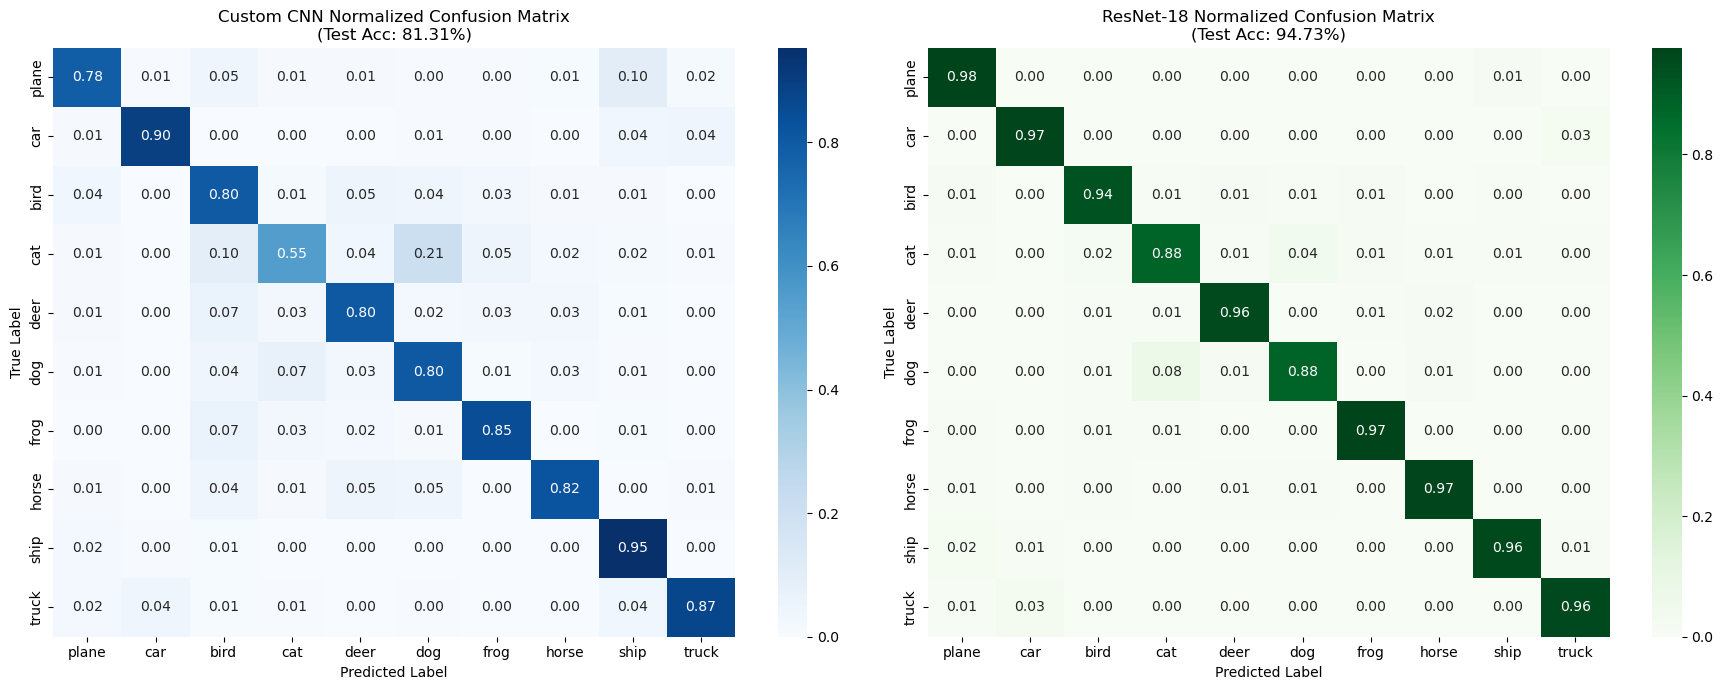

Saved Confusion matrix


In [20]:
# Confusion Matrix

c_matrix = confusion_matrix(c_y_true, c_y_pred, normalize='true')
r_matrix = confusion_matrix(r_y_true, r_y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(c_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f"Custom CNN Normalized Confusion Matrix\n(Test Acc: {c_report['accuracy']*100:.2f}%)", fontsize=12)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(r_matrix, annot=True, fmt=".2f", cmap="Greens", xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f"ResNet-18 Normalized Confusion Matrix\n(Test Acc: {r_report['accuracy']*100:.2f}%)", fontsize=12)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
os.makedirs("./figures", exist_ok=True)
plt.savefig("./figures/confusion_matrices_comparison.png", dpi=300)
plt.show()
print("Saved Confusion matrix")


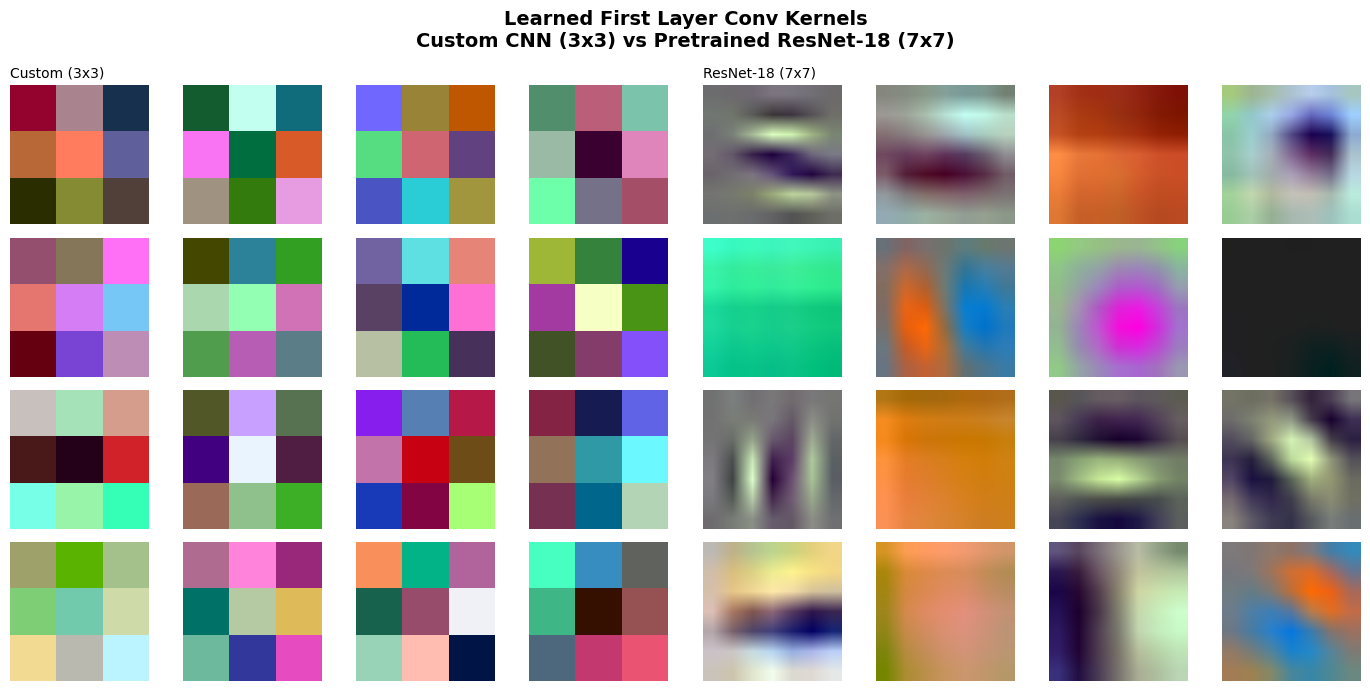

Kernel Visualization saved to './figures/first_layer_kernels.png'


In [24]:
def min_max_scale(tensor):
    t_min = tensor.min()
    t_max = tensor.max()
    return (tensor - t_min) / (t_max - t_min + 1e-8)

c_weights = c_best.conv1[0].weight.data.cpu() if isinstance(c_best.conv1, nn.Sequential) else c_best.conv1.weight.data.cpu()

r_weights = resnet_best.conv1.weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle("Learned First Layer Conv Kernels\nCustom CNN (3x3) vs Pretrained ResNet-18 (7x7)", fontsize=14, fontweight="bold")

for i in range(16):
    r = i // 4
    c = i % 4
    kernel = min_max_scale(c_weights[i]).permute(1, 2, 0).numpy()
    axes[r, c].imshow(kernel, interpolation='nearest')
    axes[r, c].axis('off')
    if r == 0 and c == 0:
        axes[r, c].set_title("Custom (3x3)", fontsize=10, loc='left')

for i in range(16):
    r = i // 4
    c = (i%4) + 4
    kernel = min_max_scale(r_weights[i]).permute(1, 2, 0).numpy()
    axes[r, c].imshow(kernel, interpolation='bilinear')
    axes[r, c].axis('off')
    if r == 0 and c == 4:
        axes[r, c].set_title("ResNet-18 (7x7)", fontsize=10, loc='left')

plt.tight_layout()
os.makedirs("./figures", exist_ok=True)
plt.savefig("./figures/first_layer_kernels.png", dpi=300, bbox_inches='tight')
plt.show()
print("Kernel Visualization saved to './figures/first_layer_kernels.png'")
